In [1]:
from pathlib import Path
import numpy as np
import json
from mpi4py import MPI
import pyvista
import dolfinx
import ldrb
import cardiac_geometries as cg
import os


In [2]:
curdir = os.getcwd()
outdir = Path('out')
meshdir = Path('Meshes/Z210')
comm = MPI.COMM_WORLD

In [3]:
os.chdir(meshdir)
geometry = cg.utils.gmsh2dolfin(comm=comm, msh_file="Z210_Merged.msh")
os.chdir(curdir)

2025-07-09 21:50:11 [debug    ] Convert file Z210_Merged.msh to dolfin
Info    : Reading 'Z210_Merged.msh'...
Info    : 5 entities
Info    : 14551 nodes
Info    : 73490 elements
Info    : Done reading 'Z210_Merged.msh'


MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


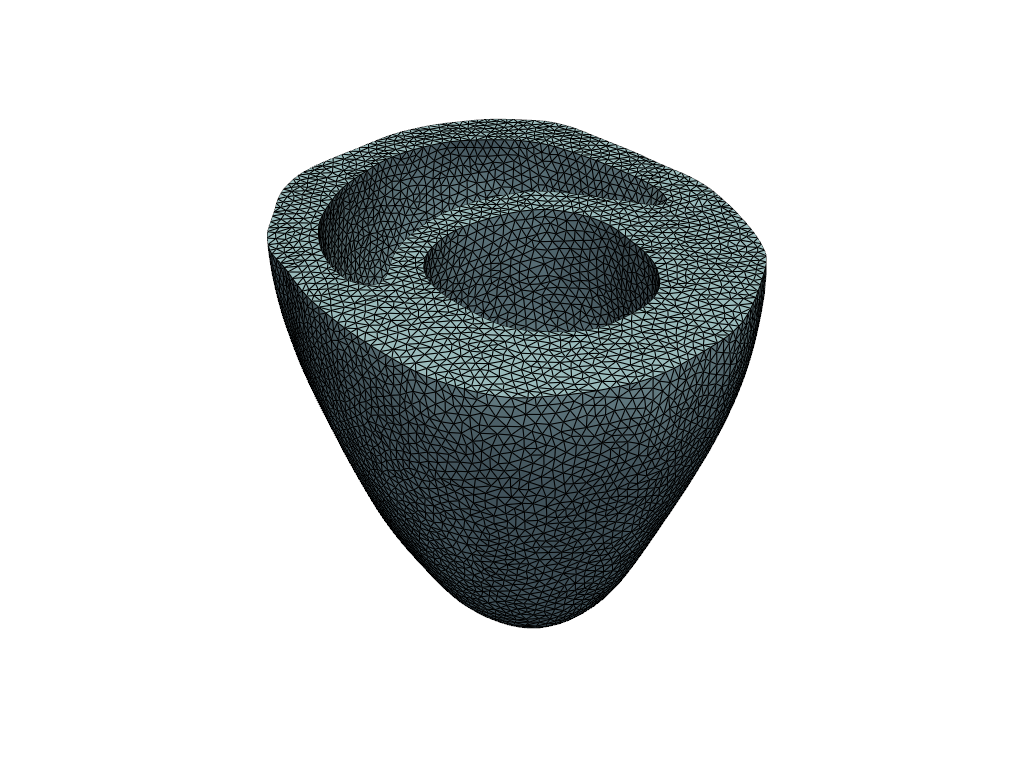

In [4]:
pyvista.start_xvfb()
vtk_mesh = dolfinx.plot.vtk_mesh(geometry.mesh, geometry.mesh.topology.dim)
grid = pyvista.UnstructuredGrid(*vtk_mesh)
plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
# plotter.camera_position = 'xy'
# plotter.camera.roll -= 45
# plotter.camera.elevation += 15
# plotter.camera.azimuth += 105
plotter.show()

In [5]:
print(geometry.markers)
if comm.rank == 0:
    (outdir / "markers.json").write_text(
        json.dumps(geometry.markers, default=cg.utils.json_serial)
    )
comm.barrier()

{'base': (1, 2), 'epi': (2, 2), 'lv': (3, 2), 'rv': (4, 2), 'vol': (5, 3)}


In [6]:
assert geometry.ffun is not None
vtk_bmesh = dolfinx.plot.vtk_mesh(
    geometry.mesh, geometry.ffun.dim, geometry.ffun.indices
)
bgrid = pyvista.UnstructuredGrid(*vtk_bmesh)
bgrid.cell_data["Facet tags"] = geometry.ffun.values
bgrid.set_active_scalars("Facet tags")
plotter = pyvista.Plotter(window_size=[800, 800])
plotter.add_mesh(bgrid, show_edges=True);


In [7]:
markers = {}
keymap = {"LV": "lv", "RV": "rv", "EPI": "epi", "base":"base"}
for k, v in geometry.markers.items():
    markers[keymap.get(k, k)] = [v[0]]

In [12]:
fiber_space = "dP_0"
#"dP_0"
#"P_1"
fiber_angle_endo = 10
fiber_angle_epi = -60
system = ldrb.dolfinx_ldrb(
    mesh=geometry.mesh,
    ffun=geometry.ffun,
    markers=markers,
    alpha_endo_lv=fiber_angle_endo,
    alpha_epi_lv=fiber_angle_epi,
    beta_endo_lv=0,
    beta_epi_lv=0,
    fiber_space=fiber_space,
)

In [13]:
fiber_space2 = "P_1"
#"dP_0"
#"P_1"
fiber_angle_endo = 10
fiber_angle_epi = -60
system2 = ldrb.dolfinx_ldrb(
    mesh=geometry.mesh,
    ffun=geometry.ffun,
    markers=markers,
    alpha_endo_lv=fiber_angle_endo,
    alpha_epi_lv=fiber_angle_epi,
    beta_endo_lv=0,
    beta_epi_lv=0,
    fiber_space=fiber_space2,
)

In [14]:
    cg.fibers.utils.save_microstructure(
    mesh=geometry.mesh, functions=(system.f0, system.s0, system.n0), outdir=outdir
)



No module named 'trame'

Falling back to a static output.
  warnings.warn(

MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


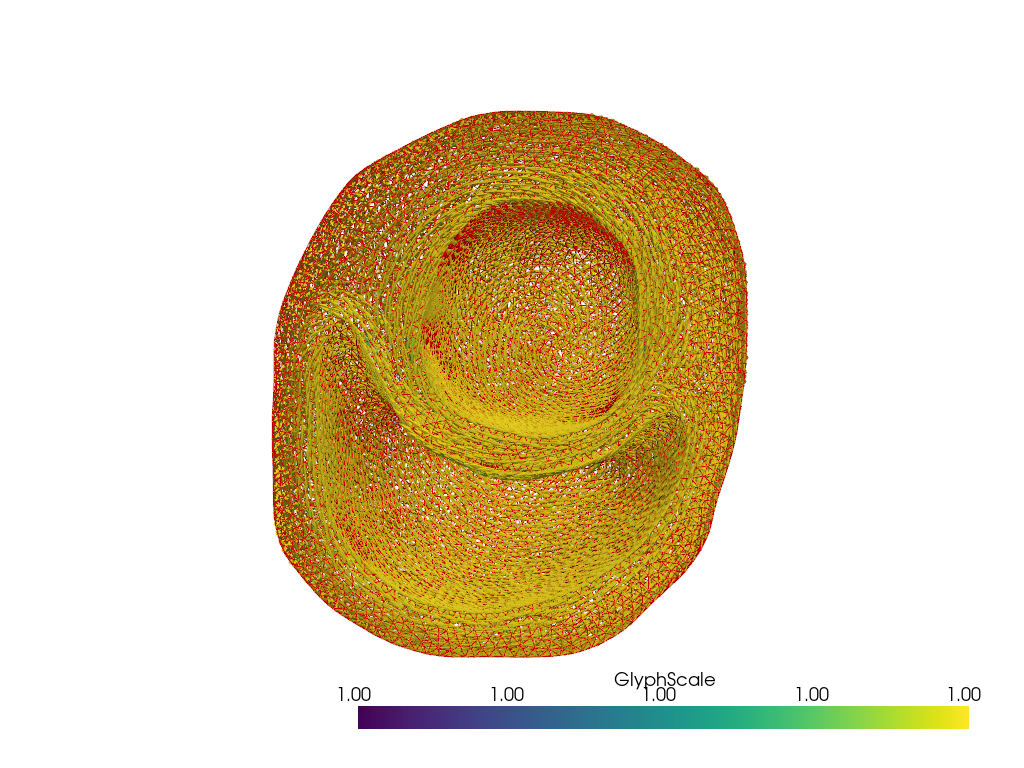

In [15]:
# Let us also plot the fibers
topology_f0, cell_types_f0, geometry_f0 = dolfinx.plot.vtk_mesh(
    system2.f0.function_space
)
values = np.zeros((geometry_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system2.f0.x.array.real.reshape(
    (geometry_f0.shape[0], len(system.f0))
)
function_grid = pyvista.UnstructuredGrid(topology_f0, cell_types_f0, geometry_f0)
function_grid["u"] = values
glyphs = function_grid.glyph(orient="u", factor=1.0)
grid = pyvista.UnstructuredGrid(*vtk_mesh)
plotter = pyvista.Plotter()
plotter.add_mesh(grid, style="wireframe", color="r")
plotter.add_mesh(glyphs)
plotter.view_xy()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    fig_as_array = plotter.screenshot("fiber_ukb.png")

In [16]:
values = np.zeros((cell_types_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system.f0.x.array.real.reshape((cell_types_f0.shape[0], len(system.f0)))
fibers_f0 = values

values = np.zeros((cell_types_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system.s0.x.array.real.reshape((cell_types_f0.shape[0], len(system.f0)))
fibers_s0 = values

values = np.zeros((cell_types_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system.n0.x.array.real.reshape((cell_types_f0.shape[0], len(system.f0)))
fibers_n0 = values

In [17]:
geometry_f0.shape[0]

14551

In [18]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

fiber_array = fibers_f0  # shape (n_elements, 3)
sheet_array = fibers_s0

mesh_data = ET.Element('MeshData')
element_data_tag = ET.SubElement(mesh_data, 'ElementData', {'type': "mat_axis",'elem_set': "Part1"})

for eid, fvec in enumerate(fiber_array):
    svec = sheet_array[eid]        
        
    e_tag = ET.SubElement(element_data_tag, "e", lid=str(eid+1))
    
    a_tag = ET.SubElement(e_tag, 'a')
    a_tag.text = f"{fvec[0]:.6f}, {fvec[1]:.6f}, {fvec[2]:.6f}"
    
    b_tag = ET.SubElement(e_tag, 'b')
    b_tag.text = f"{svec[0]:.6f}, {svec[1]:.6f}, {svec[2]:.6f}"

# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(mesh_data)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("fiber_data.xml", 'w') as f:
    f.write(xml_str)

In [19]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

mesh = geometry.mesh  # Assuming your mesh is stored in `geo.mesh`
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
connectivity = mesh.topology.connectivity(tdim, 0)  # Cell-to-vertex connectivity

mesh_data = ET.Element('Mesh')
node_data_tag = ET.SubElement(mesh_data, 'Nodes', {'name': "merged"})

for node_index in range(geometry_f0.shape[0]):
    coordinates = mesh.geometry.x[node_index]
    node_tag = ET.SubElement(node_data_tag, "node", {'id': str(node_index+1)})
    node_tag.text = f"{coordinates[0]:.6f}, {coordinates[1]:.6f}, {coordinates[2]:.6f}"

element_data_tag = ET.SubElement(mesh_data, 'Elements', {'type':"tet4", 'name':"Part1"})

for cell_index in range(num_cells):
    vertices = connectivity.links(cell_index)
    vertices = vertices+1
    element_tag = ET.SubElement(element_data_tag, "elem", {'id': str(cell_index+1)})
    element_tag.text = f"{vertices[0]}, {vertices[1]}, {vertices[2]}, {vertices[3]}"

    
# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(mesh_data)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("mesh_data.xml", 'w') as f:
    f.write(xml_str)    

In [ ]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

mesh = geometry.mesh  # Assuming your mesh is stored in `geo.mesh`
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
connectivity = mesh.topology.connectivity(tdim, 0)  # Cell-to-vertex connectivity

mesh_data = ET.Element('Mesh')
node_data_tag = ET.SubElement(mesh_data, 'Nodes', {'name': "merged"})

for node_index in range(geometry_f0.shape[0]):
    coordinates = mesh.geometry.x[node_index]
    node_tag = ET.SubElement(node_data_tag, "node", {'id': str(node_index+1)})
    node_tag.text = f"{coordinates[0]:.6f}, {coordinates[1]:.6f}, {coordinates[2]:.6f}"

element_data_tag = ET.SubElement(mesh_data, 'Elements', {'type':"tet4", 'name':"Part1"})

for cell_index in range(num_cells):
    vertices = connectivity.links(cell_index)
    vertices = vertices+1
    element_tag = ET.SubElement(element_data_tag, "elem", {'id': str(cell_index+1)})
    element_tag.text = f"{vertices[0]}, {vertices[1]}, {vertices[2]}, {vertices[3]}"


fiber_array = fibers_f0  # shape (n_elements, 3)
sheet_array = fibers_s0

mesh_data = ET.Element('MeshData')
element_data_tag = ET.SubElement(mesh_data, 'ElementData', {'type': "mat_axis",'elem_set': "Part1"})


for eid, fvec in enumerate(fiber_array):
    svec = sheet_array[eid]        
        
    e_tag = ET.SubElement(element_data_tag, "e", lid=str(eid+1))
    
    a_tag = ET.SubElement(e_tag, 'a')
    a_tag.text = f"{fvec[0]:.6f}, {fvec[1]:.6f}, {fvec[2]:.6f}"
    
    b_tag = ET.SubElement(e_tag, 'b')
    b_tag.text = f"{svec[0]:.6f}, {svec[1]:.6f}, {svec[2]:.6f}"



# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(mesh_data)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("combined.xml", 'w') as f:
    f.write(xml_str)    

In [20]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

mesh = geometry.mesh  # Assuming your mesh is stored in `geo.mesh`
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
connectivity = mesh.topology.connectivity(tdim, 0)  # Cell-to-vertex connectivity

main_xml = ET.Element("febio_spec", {'version': "4.0"})

module = ET.SubElement(main_xml,"Module", {"type":"solid"})
ETglobals = ET.SubElement(main_xml,"Globals")
ETconstants = ET.SubElement(ETglobals,"Constants")
T_const = ET.SubElement(ETconstants,"T")
T_const.text = '0'
P_const = ET.SubElement(ETconstants,"P")
P_const.text = '0'
R_const = ET.SubElement(ETconstants,"R")
R_const.text = '31446'
Fc_const = ET.SubElement(ETconstants,"Fc")
Fc_const.text = '96485.3'

mesh_tag = ET.SubElement(main_xml,'Mesh')
node_data_tag = ET.SubElement(mesh_tag, 'Nodes', {'name': "merged"})

for node_index in range(geometry_f0.shape[0]):
    coordinates = mesh.geometry.x[node_index]
    node_tag = ET.SubElement(node_data_tag, "node", {'id': str(node_index+1)})
    node_tag.text = f"{coordinates[0]:.6f}, {coordinates[1]:.6f}, {coordinates[2]:.6f}"

element_data_tag = ET.SubElement(mesh_tag, 'Elements', {'type':"tet4", 'name':"Part1"})

for cell_index in range(num_cells):
    vertices = connectivity.links(cell_index)
    vertices = vertices+1
    element_tag = ET.SubElement(element_data_tag, "elem", {'id': str(cell_index+1)})
    element_tag.text = f"{vertices[0]}, {vertices[1]}, {vertices[2]}, {vertices[3]}"



mesh_domain = ET.SubElement(main_xml,'MeshDomains')
solid_domain = ET.SubElement(mesh_domain, 'SolidDomain', {'name':"Part1", 'mat':""})


fiber_array = fibers_f0  # shape (n_elements, 3)
sheet_array = fibers_s0

mesh_data = ET.SubElement(main_xml,'MeshData')
element_data_tag = ET.SubElement(mesh_data, 'ElementData', {'type': "mat_axis",'elem_set': "Part1"})


for eid, fvec in enumerate(fiber_array):
    svec = sheet_array[eid]        
        
    # e_tag = ET.SubElement(element_data_tag, "e", lid=str(eid+1))
    e_tag = ET.SubElement(element_data_tag, "elem", lid=str(eid+1))
    
    a_tag = ET.SubElement(e_tag, 'a')
    a_tag.text = f"{fvec[0]:.6f}, {fvec[1]:.6f}, {fvec[2]:.6f}"
    
    b_tag = ET.SubElement(e_tag, 'd')
    b_tag.text = f"{svec[0]:.6f}, {svec[1]:.6f}, {svec[2]:.6f}"



#step = ET.SubElement(main_xml,'Step')
output = ET.SubElement(main_xml,'Output')
out_plotfile = ET.SubElement(output,'plotfile',{"type":"febio"})
disp = ET.SubElement(out_plotfile,'var',{"type":"displacement"})
stress = ET.SubElement(out_plotfile,'var',{"type":"stress"})
rel_vol = ET.SubElement(out_plotfile,'var',{"type":"relative volume"})


# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(main_xml)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("combined.xml", 'w') as f:
    f.write(xml_str)    

# Write the XML string to a file
with open("combined.feb", 'w') as f:
    f.write(xml_str)    

In [ ]:
[fibers_f0]

In [ ]:
import meshio
import numpy as np

values = np.zeros((geometry_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system2.f0.x.array.real.reshape(
    (geometry_f0.shape[0], len(system.f0))
)
point_vectors = values

# Extract mesh data for meshio
cells = mesh.topology.connectivity(mesh.topology.dim, 0).array.reshape(-1, 4)
# Convert mesh coordinates and cells for meshio
points = mesh.geometry.x.copy()
cells_dict = { "tetra": cells }

# Create meshio.Mesh object
meshio_mesh = meshio.Mesh(
    points=points,
    cells=[("tetra", cells)],
    cell_data={"fiber_vectors": [fibers_f0]},  # must be a list of arrays
    point_data = {"point_fiber_vectors" : point_vectors}
)

# Write to .vtk file
meshio.write("fibers.vtk", meshio_mesh)

In [ ]:
print("points.shape:", points.shape)
print("cells.shape:", cells.shape)
print("fibers_f0.shape:", fibers_f0.shape)  # Should be (num_cells, 3)